In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

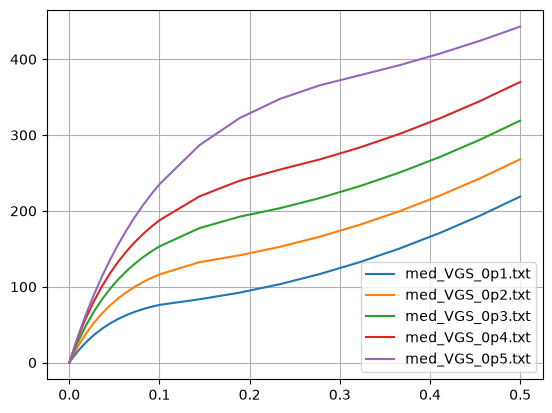

In [4]:
archivos = [
    "med_VGS_0p1.txt",
    "med_VGS_0p2.txt",
    "med_VGS_0p3.txt",
    "med_VGS_0p4.txt",
    "med_VGS_0p5.txt",

]

plt.figure()

for archivo in archivos:
    datos = np.loadtxt(archivo)

    plt.plot(
        datos[:, 0],
        datos[:, 1],
        label=archivo
    )

plt.legend()
plt.grid()
plt.show()

In [5]:
import numpy as np

archivos = [
    "med_VGS_0p1.txt",
    "med_VGS_0p2.txt",
    "med_VGS_0p3.txt",
    "med_VGS_0p4.txt",
    "med_VGS_0p5.txt",
]

for archivo in archivos:
    # Leer datos
    datos = np.loadtxt(archivo)

    # Multiplicar la segunda columna por 1e-6
    datos[:, 1] *= 1e-6

    # Nombre del nuevo archivo
    nuevo_archivo = archivo.replace(".txt", "_uA.txt")

    # Guardar
    np.savetxt(
        nuevo_archivo,
        datos,
        fmt="%.8f %.12e"  # primera columna decimal, segunda en notación científica
    )

print("Archivos generados correctamente.")

Archivos generados correctamente.


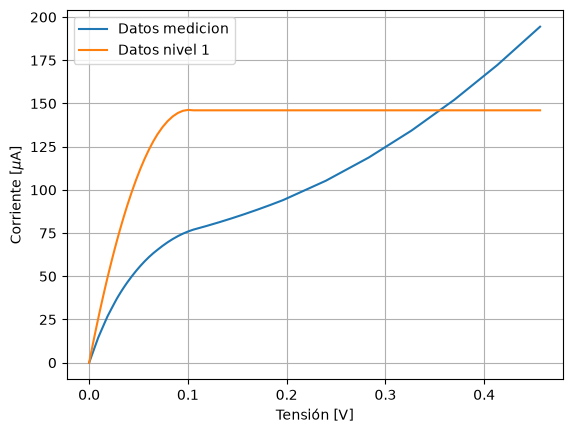

In [11]:
datos_lvl1 = np.loadtxt("simulacion_lvl_1", skiprows = 1)

plt.figure()
plt.plot(datos_lvl1[:, 0], 1e6*datos_lvl1[:, 1], label = "Datos medicion")
plt.plot(datos_lvl1[:, 0], 1e6*datos_lvl1[:, 2], label = "Datos nivel 1")
plt.legend()
plt.xlabel("Tensión [V]")
plt.ylabel(r"Corriente [$\mu$A]")
plt.grid()

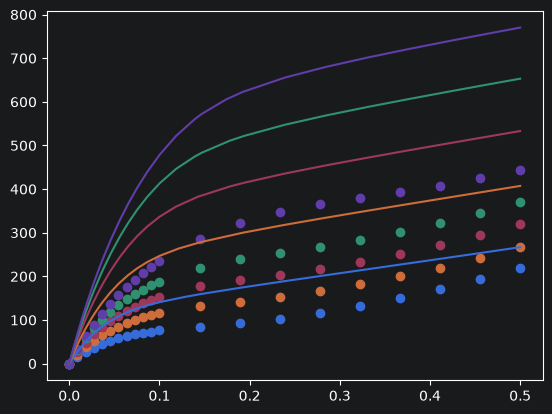

In [17]:
datos_sin_ajuste_lvl49_0p1 = np.loadtxt("lvl_49_sin_ajuste_0p1.txt")
datos_sin_ajuste_lvl49_0p2 = np.loadtxt("lvl_49_sin_ajuste_0p2.txt")
datos_sin_ajuste_lvl49_0p3 = np.loadtxt("lvl_49_sin_ajuste_0p3.txt")
datos_sin_ajuste_lvl49_0p4 = np.loadtxt("lvl_49_sin_ajuste_0p4.txt")
datos_sin_ajuste_lvl49_0p5 = np.loadtxt("lvl_49_sin_ajuste_0p5.txt")

plt.figure()

for archivo in archivos:
    datos = np.loadtxt(archivo)

    plt.scatter(
        datos[:, 0],
        datos[:, 1],
        label=archivo
    )

plt.plot(datos_sin_ajuste_lvl49_0p1[:,0], 1e6*datos_sin_ajuste_lvl49_0p1[:,1])

plt.plot(datos_sin_ajuste_lvl49_0p2[:,0], 1e6*datos_sin_ajuste_lvl49_0p2[:,1])

plt.plot(datos_sin_ajuste_lvl49_0p3[:,0], 1e6*datos_sin_ajuste_lvl49_0p3[:,1])

plt.plot(datos_sin_ajuste_lvl49_0p4[:,0], 1e6*datos_sin_ajuste_lvl49_0p4[:,1])

plt.plot(datos_sin_ajuste_lvl49_0p5[:,0], 1e6*datos_sin_ajuste_lvl49_0p5[:,1])

plt.show()

Los puntos representan a las mediciones del set de datos proporcionado, y las lineas continuas las simulaciones de ltspice

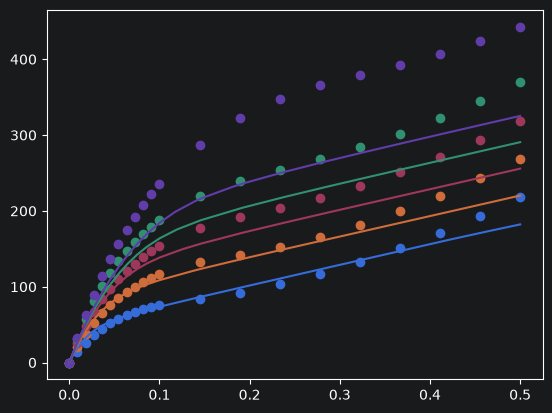

In [19]:
datos_ajustados_lvl49_0p1 = np.loadtxt("datos_ajustados_lvl_49_0p1.txt")
datos_ajustados_lvl49_0p2 = np.loadtxt("datos_ajustados_lvl_49_0p2.txt")
datos_ajustados_lvl49_0p3 = np.loadtxt("datos_ajustados_lvl_49_0p3.txt")
datos_ajustados_lvl49_0p4 = np.loadtxt("datos_ajustados_lvl_49_0p4.txt")
datos_ajustados_lvl49_0p5 = np.loadtxt("datos_ajustados_lvl_49_0p5.txt")

plt.figure()

for archivo in archivos:
    datos = np.loadtxt(archivo)

    plt.scatter(
        datos[:, 0],
        datos[:, 1],
        label=archivo
    )

plt.plot(datos_ajustados_lvl49_0p1[:,0], 1e6*datos_ajustados_lvl49_0p1[:,1])

plt.plot(datos_ajustados_lvl49_0p2[:,0], 1e6*datos_ajustados_lvl49_0p2[:,1])

plt.plot(datos_ajustados_lvl49_0p3[:,0], 1e6*datos_ajustados_lvl49_0p3[:,1])

plt.plot(datos_ajustados_lvl49_0p4[:,0], 1e6*datos_ajustados_lvl49_0p4[:,1])

plt.plot(datos_ajustados_lvl49_0p5[:,0], 1e6*datos_ajustados_lvl49_0p5[:,1])

plt.show()

Los puntos representan a las mediciones del set de datos proporcionado, y las lineas continuas las simulaciones de ltspice

La directiva utilizada fue:

**.MODEL mi_nmos NMOS(LEVEL=49 TOX=1.2e-9 U0=1015 VTH0=0.034 UA = 1e-8 UB = 4e-19 VSAT = 2.5e4 ETA0 = 0.5)**

En la region lineal se ajustaron los parametros de degradacion de la movilidad modifciando los valores de UA y UB, esto sirvio para obtener la separacion correcta
entre las distintas curvas
Luego se ajusto la velocidad de saturacion hasta hacer coinicidir la ubicacion de los codos. Este fue el efecto que mas se destacaba y que mejor se logro ajustar.
Al final se ajusto el eta0 para intentar reflejar el efecto DIBL que era muy evidente en las curvas medidas. Este no se logro ajustar de manera satisfactoria.
No se ajusto el parametro PCLM porque la corriente no saturaba por modulacion de largo de canal sino por saturacion de la velocidad.